In [1]:
import numpy as np
import do_mpc
from casadi import *
from do_mpc.model import Model
from do_mpc.controller import MPC
from do_mpc.simulator import Simulator
import matplotlib.pyplot as plt

# Create the model
model_type = 'continuous'  # Continuous-time model
model = Model(model_type)

# Define state variables
x1 = model.set_variable('_x', 'x1')  # Position (angle)
x2 = model.set_variable('_x', 'x2')  # Velocity

# Define control input
u = model.set_variable('_u', 'u')

# Define system parameters
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A, B = -g / l, -b / (m * l**2)

# Define nonlinear system dynamics
f1 = x2
#f2 = A * sin(x1) + B * x2 + u  # Nonlinear pendulum equation with control
f2 = -x1 * (3.14/2  + arctan(5 * x1)) - (5 * x1**2 / (2 * (1 + 25 * x1**2))) + 4 * x2 + 3 * u
    

# Set right-hand side (RHS) of system equations
model.set_rhs('x1', f1)
model.set_rhs('x2', f2)

# Finalize model
model.setup()

In [14]:
mpc = MPC(model)

t_step = 0.5
# Set time step and prediction horizon
mpc.set_param(n_horizon=20, t_step=t_step)

# Define cost function weights
Q = np.diag([1, 1])  # State cost matrix
R = np.diag([0.1])   # Control cost

mpc.set_objective(
    lterm= Q[0, 0] * x1**2 + Q[1, 1] * x2**2 + R[0, 0] * u**2,  # Running cost
    mterm= Q[0, 0] * x1**2 + Q[1, 1] * x2**2  # Terminal cost (optional)
)

mpc.set_rterm(
    u=0.1  # Adjust this value to balance responsiveness and smoothness
)

# Input constraints (control effort limits)
mpc.bounds['lower', '_u', 'u'] = -10
mpc.bounds['upper', '_u', 'u'] = 10

# Setup optimizer
mpc.setup()

In [ ]:
# Create simulator
simulator = Simulator(model)
simulator.set_param(t_step=t_step)
simulator.setup()

# Set initial condition
x0 = np.array([3, -2])  # Initial angle and velocity
mpc.x0 = x0
simulator.x0 = x0

# Simulate for 100 steps
n_steps = 100
u_list = []
x_list = [x0]

for i in range(n_steps):
    u_cmd = mpc.make_step(x0)  # Solve MPC problem
    x_next = simulator.make_step(u_cmd)  # Simulate system
    u_list.append(u_cmd)
    x_list.append(x_next)
    x0 = x_next  # Update state

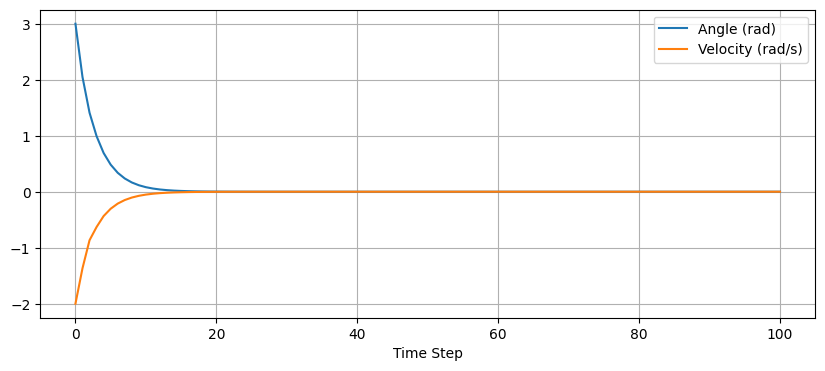

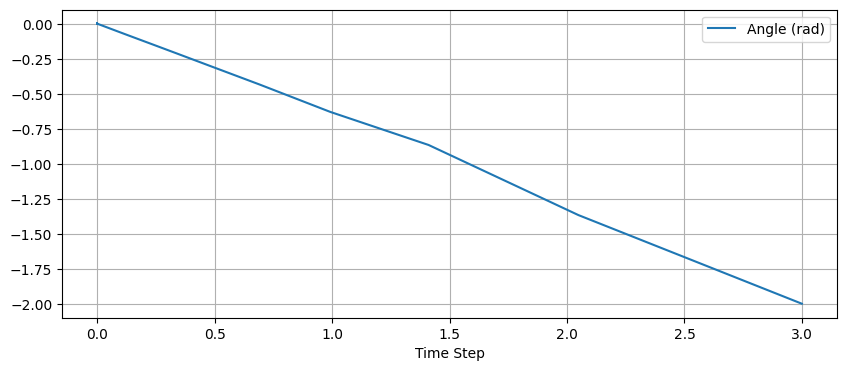

In [16]:
# Convert results to NumPy array
x_list = np.array([np.array(x).flatten() for x in x_list])

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(x_list[:, 0], label='Angle (rad)')
plt.plot(x_list[:, 1], label='Velocity (rad/s)')
plt.xlabel("Time Step")
plt.legend()
plt.grid()
plt.show()

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(x_list[:, 0], x_list[:, 1], label='Angle (rad)')
plt.xlabel("Time Step")
plt.legend()
plt.grid()
plt.show()